# 🔬 Advanced Race Analysis
## `Barcelona` · `2026` Formula 1 World Championship

Three deeper analyses for a single session:
1. **Race pace distribution** — true pace per driver (box plot of clean laps)
2. **Tyre degradation** — lap time vs tyre age, regressed per compound
3. **Track dominance map** — circuit coloured by fastest driver per mini-sector

---

In [1]:
YEAR       = 2026
GRAND_PRIX = 'Barcelona'
SESSION    = 'R'        # 'R' for pace & degradation; 'Q' is fine for dominance

# Drivers for the track dominance map (None = auto top-3 fastest laps)
DOMINANCE_DRIVERS = None   # e.g. ['VER', 'NOR', 'LEC']

In [2]:
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
_root = _here
for _ in range(5):
    if (_root / 'utils' / 'f1_helpers.py').exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

from utils.f1_helpers import (
    setup, ensure_assets_dir,
    plot_race_pace, tyre_degradation_summary, plot_tyre_degradation,
    plot_track_dominance,
)
import fastf1

setup('content/f1_cache')
ASSETS = ensure_assets_dir('assets')

session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load(telemetry=True, weather=False)
print(f'\n✅ Loaded: {session.event["EventName"]} {YEAR} — {SESSION}')

core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '23', '14', '27', '77', '18']



✅ Loaded: Barcelona Grand Prix 2026 — R


---
## 1 · Race Pace Distribution

req            INFO 	Using cached data for driver_info
findfont: Failed to find font weight medium, now using 400.


Saved → assets\P1_race_pace.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_67712\2745043308.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


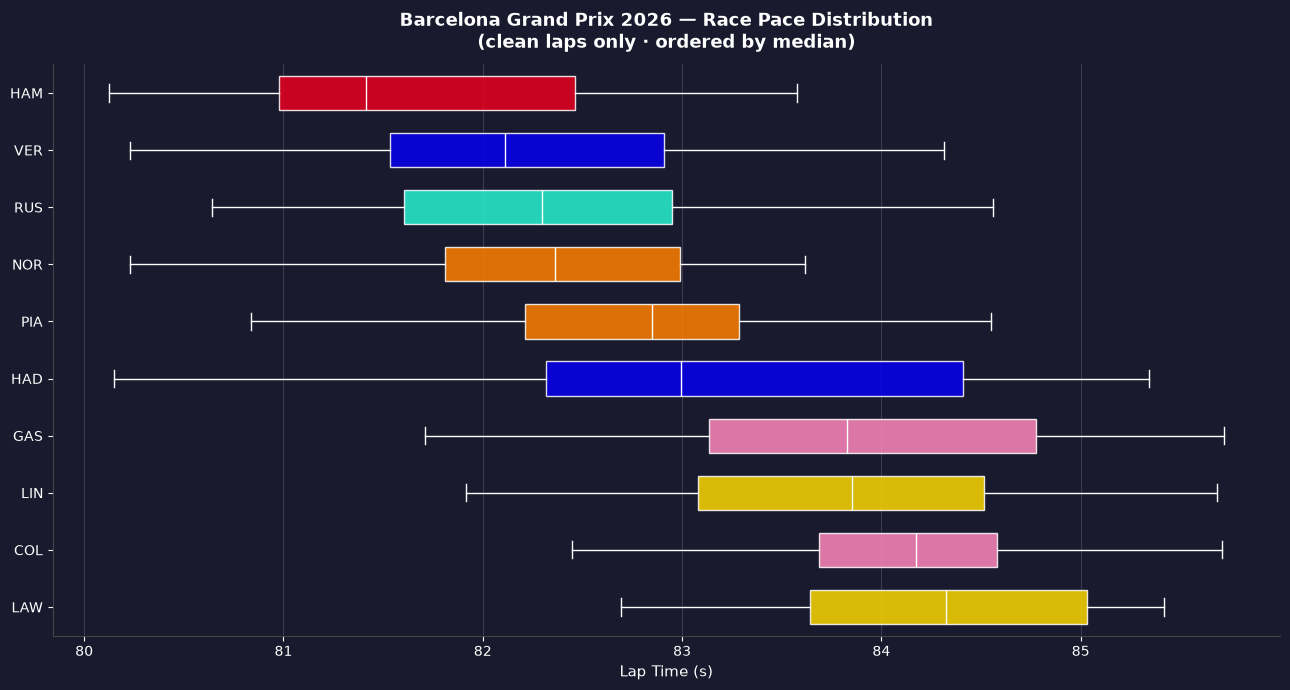

In [3]:
fig1 = plot_race_pace(session, top_n=10, assets_path=ASSETS)
fig1.show()

---
## 2 · Tyre Degradation

> Slope = seconds lost per lap of tyre age. Not fuel-corrected, so treat as a trend:
> early-stint fuel burn can mask wear. Compare the *relative* slopes between compounds.

In [4]:
tyre_degradation_summary(session)

,Compound,Laps,DegRate_s_per_lap,BaseLap_s
0,SOFT,79,0.0103,83.756
1,MEDIUM,198,0.0413,83.151
2,HARD,584,0.0177,82.936


Saved → assets\P2_tyre_degradation.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_67712\2357879445.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


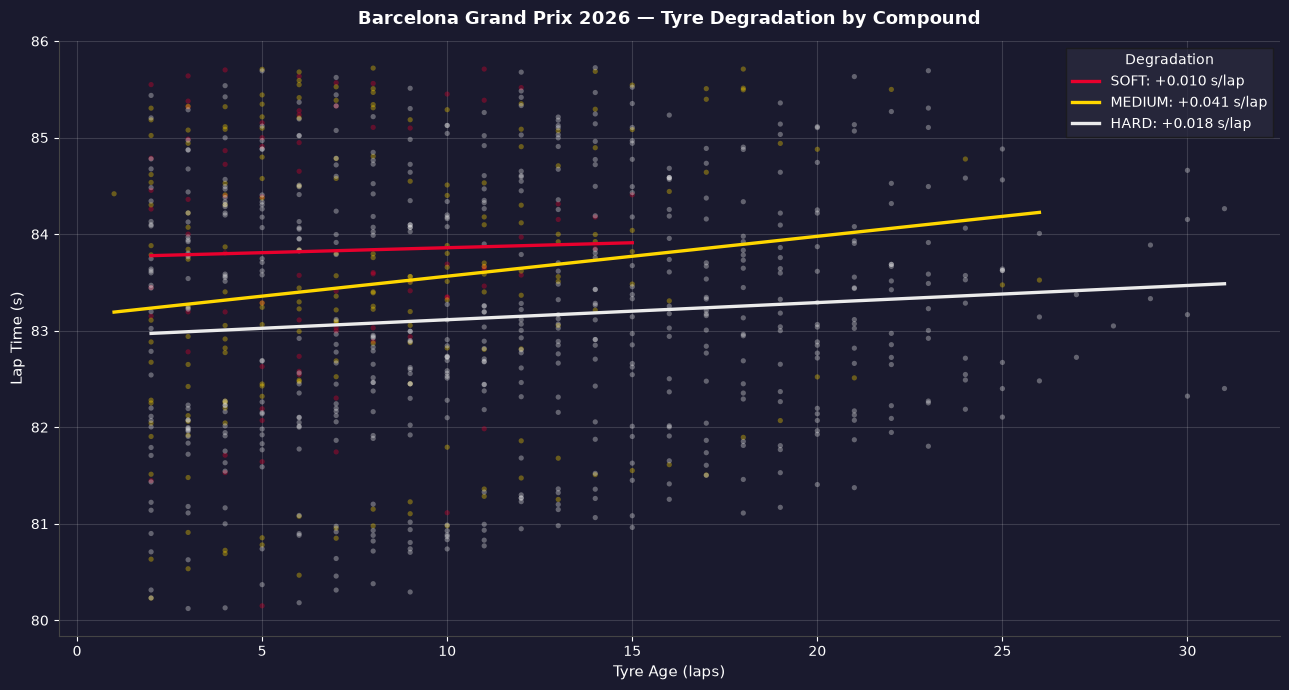

In [5]:
fig2 = plot_tyre_degradation(session, assets_path=ASSETS)
fig2.show()

---
## 3 · Track Dominance Map

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Saved → assets\P3_track_dominance.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_67712\1229723854.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()


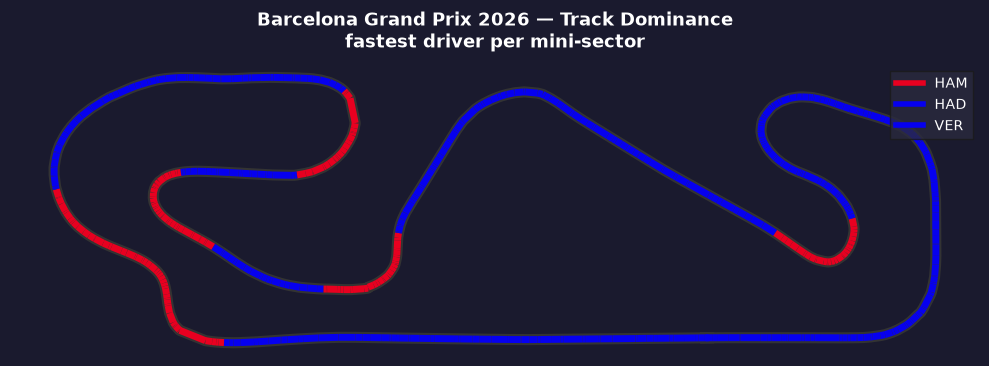

In [6]:
fig3 = plot_track_dominance(session, drivers=DOMINANCE_DRIVERS, assets_path=ASSETS)
fig3.show()

---
## Assets generated

| File | Use for |
|------|---------|
| `P1_race_pace.png` | Race pace box plot — clean, rankable |
| `P2_tyre_degradation.png` | Degradation regression — analyst credibility |
| `P3_track_dominance.png` | Track dominance map — highest engagement |